# Conductivity ratio (`k1/k2`) error comparison using `Solver`

`k2 = 1.0` is fixed. `k1` is varied across values ≤ 1.0.
The **first** entry in `k1_list` (`k1 = 1.0`, ratio = 1) is the **reference**.

`Lz`, `nz`, and `z_dis` are all fixed so every run shares the same `z` grid —
no interpolation needed.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=8.0, nz=80, tf=2.0, n_t_out=400, device='cuda')
Available keys: ['U', 'U_raw', 'W', 'dataset', 'kratio', 'stau', 't', 'z', 'z_dis']
U      : torch.Size([81, 400])
U_raw  : torch.Size([81, 400])
z      : torch.Size([81])
t      : torch.Size([400])
stau   : torch.Size([32400, 2])
W      : torch.Size([32400, 1])


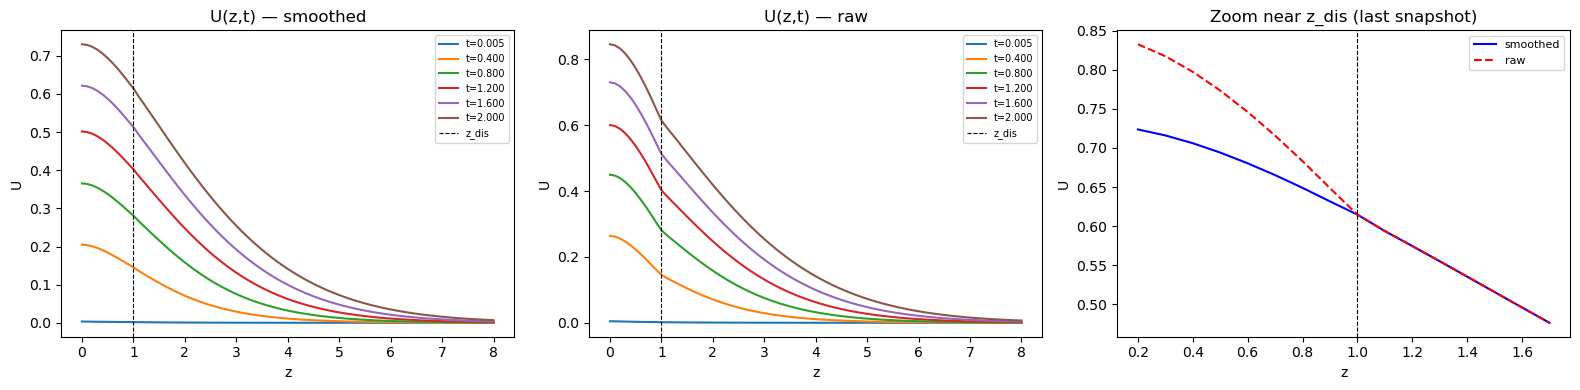

Dataset saved to ./data/2layer_k11.0_k22.0_nz80.pt


In [12]:
%run func_defs.ipynb
%run 2L_NN_v7.ipynb

## Parameters

Edit `k1_list` to change which ratios are tested.
First entry is always the reference.

In [21]:
# ── fixed physics ───────────────────────────────────────────────────────
k2      = 1.0           # fixed
z_dis   = 1.0
Pda     = 1.0
tf      = 2.0
Lz      = 16.0

# ── grid ─────────────────────────────────────────────────────────────────
nz_unit = 10
nz      = int(Lz) * nz_unit
n_t_out = 80

# ── k1 values to sweep (first = reference, ratio k1/k2 = 1) ─────────────
k1_list = [.50, .25,0.75, 1]

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device},  k2={k2},  Lz={Lz},  nz={nz},  z_dis={z_dis}')
print(f'k1/k2 ratios tested: {[round(k1/k2, 4) for k1 in k1_list]}')

device: cuda,  k2=1.0,  Lz=16.0,  nz=160,  z_dis=1.0
k1/k2 ratios tested: [0.5, 0.25, 0.75, 1.0]


## Run `Solver` for each `k1`

In [22]:
solvers = {}   # k1 -> Solver instance

for k1 in k1_list:
    print(f'\n=== k1={k1},  ratio={k1/k2:.4f} ===')
    solvers[k1] = Solver(
        k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
        Lz=Lz, nz=nz, tf=tf, n_t_out=n_t_out,
        device=device, verbose=True,
    )
    print(f'  U shape: {solvers[k1]["U"].shape}')


=== k1=0.5,  ratio=0.5000 ===
Interface alignment error: 0.00e+00
n_fine=400, dt=5.0000e-03, tf=2.0
  U shape: torch.Size([161, 80])

=== k1=0.25,  ratio=0.2500 ===
Interface alignment error: 0.00e+00
n_fine=400, dt=5.0000e-03, tf=2.0
  U shape: torch.Size([161, 80])

=== k1=0.75,  ratio=0.7500 ===
Interface alignment error: 0.00e+00
n_fine=400, dt=5.0000e-03, tf=2.0
  U shape: torch.Size([161, 80])

=== k1=1,  ratio=1.0000 ===
Interface alignment error: 0.00e+00
n_fine=400, dt=5.0000e-03, tf=2.0
  U shape: torch.Size([161, 80])


## Compute errors vs the reference (`k1 = 1.0`)

In [23]:
k1_ref = k1_list[0]                  # reference: k1=1.0 (ratio=1)
U_ref  = solvers[k1_ref]['U']        # (nz+1, n_t_out)
z_grid = solvers[k1_ref]['z']        # shared z grid
t_out  = solvers[k1_ref]['t']        # shared time grid

errors_abs = {}   # k1 -> (nz+1, n_t_out)
errors_rel = {}

for k1 in k1_list[1:]:
    diff = (solvers[k1]['U'] - U_ref).abs()
    errors_abs[k1] = diff
    errors_rel[k1] = diff / (U_ref.abs() + 1e-40)

print(f'  {"k1":>6}  {"ratio":>8}  {"max |err|":>12}  {"mean |err|":>12}  {"max rel err":>12}')
print('-' * 58)
for k1, err in errors_abs.items():
    rel = errors_rel[k1]
    print(f'  {k1:>6.3f}  {k1/k2:>8.4f}  {err.max().item():>12.4e}'
          f'  {err.mean().item():>12.4e}  {rel.max().item():>12.4e}')

      k1     ratio     max |err|    mean |err|   max rel err
----------------------------------------------------------
   0.250    0.2500    9.7277e-02    5.8522e-03    2.1716e-01
   0.750    0.7500    3.9819e-02    2.9893e-03    2.0357e-01
   1.000    1.0000    6.1532e-02    4.7840e-03    3.9643e-01


## Plots

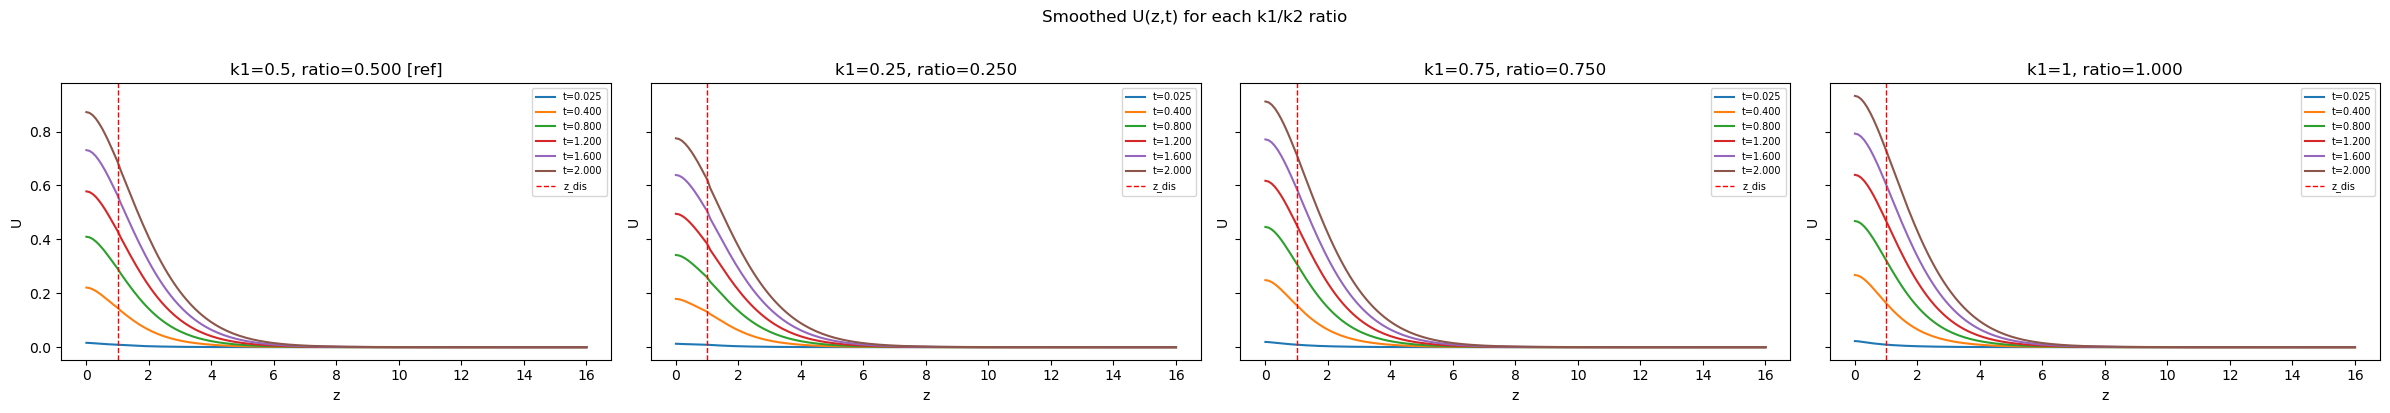

In [24]:
n_runs = len(k1_list)
idx    = torch.linspace(0, n_t_out - 1, min(6, n_t_out)).long()
t_cpu  = t_out.cpu()
z_cpu  = z_grid.cpu()

fig, axes = plt.subplots(1, n_runs, figsize=(6 * n_runs, 4), sharey=True)
if n_runs == 1:
    axes = [axes]

for ax, k1 in zip(axes, k1_list):
    U_plot = solvers[k1]['U'].cpu()
    for i in idx:
        ax.plot(z_cpu, U_plot[:, i], label=f't={t_cpu[i]:.3f}')
    ax.axvline(z_dis, color='r', linestyle='--', lw=1.0, label='z_dis')
    tag = ' [ref]' if k1 == k1_ref else ''
    ax.set_xlabel('z'); ax.set_ylabel('U')
    ax.set_title(f'k1={k1}, ratio={k1/k2:.3f}{tag}')
    ax.legend(fontsize=7)

plt.suptitle('Smoothed U(z,t) for each k1/k2 ratio', y=1.02)
plt.tight_layout()
plt.show()

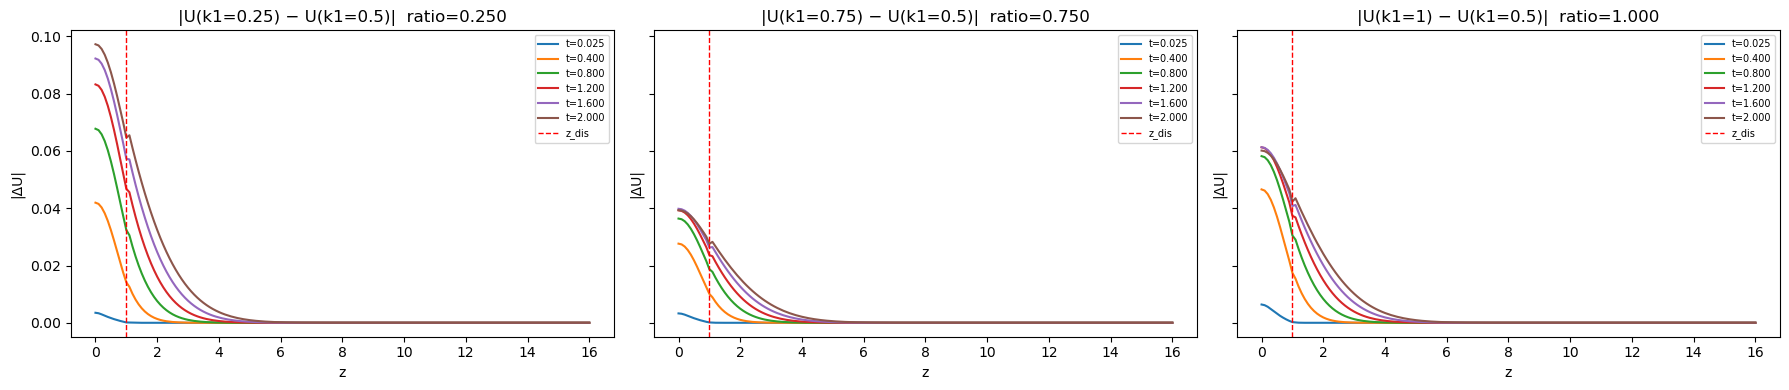

In [36]:
n_err = len(errors_abs)
fig, axes = plt.subplots(1, n_err, figsize=(6 * n_err, 4), sharey=True)
if n_err == 1:
    axes = [axes]

for ax, (k1, err) in zip(axes, errors_abs.items()):
    err_cpu = err.cpu()
    for i in idx:
        ax.plot(z_cpu, err_cpu[:, i], label=f't={t_cpu[i]:.3f}')
    ax.axvline(z_dis, color='r', linestyle='--', lw=1.0, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
    ax.set_title(f'|U(k1={k1}) − U(k1={k1_ref})|  ratio={k1/k2:.3f}')
    ax.legend(fontsize=7)

#plt.suptitle(f'Absolute error vs reference (k1={k1_ref}, ratio={k1_ref})', y=1.02)
plt.savefig(f'Error_kratio_ref{k1_ref}.pdf')
plt.tight_layout()
plt.show()

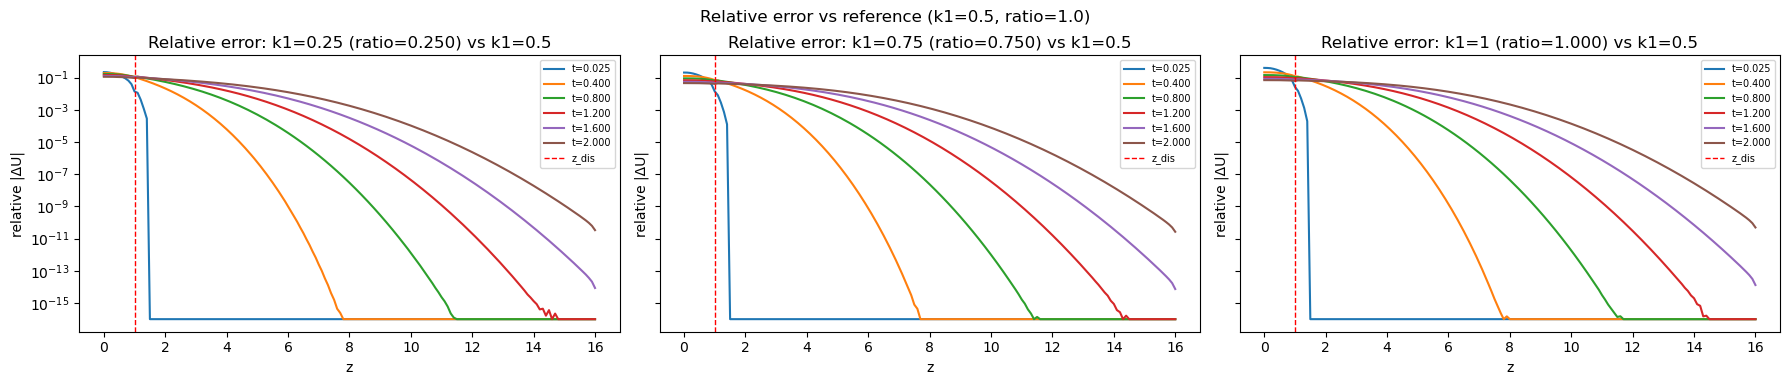

In [35]:
fig, axes = plt.subplots(1, n_err, figsize=(6 * n_err, 4), sharey=True)
if n_err == 1:
    axes = [axes]

for ax, (k1, rel) in zip(axes, errors_rel.items()):
    rel_cpu = rel.cpu()
    for i in idx:
        ax.semilogy(z_cpu, rel_cpu[:, i].clamp(min=1e-16), label=f't={t_cpu[i]:.3f}')
    ax.axvline(z_dis, color='r', linestyle='--', lw=1.0, label='z_dis')
    ax.set_xlabel('z'); ax.set_ylabel('relative |ΔU|')
    ax.set_title(f'Relative error: k1={k1} (ratio={k1/k2:.3f}) vs k1={k1_ref}')
    ax.legend(fontsize=7)

#plt.suptitle(f'Relative error vs reference (k1={k1_ref}, ratio=1.0)', y=.95)
plt.tight_layout()
plt.show()

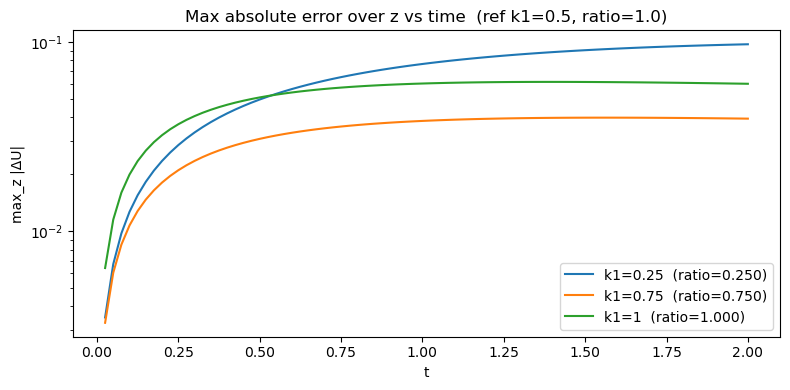

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

for k1, err in errors_abs.items():
    max_err_t = err.max(dim=0).values.cpu()
    ax.semilogy(t_cpu, max_err_t, label=f'k1={k1}  (ratio={k1/k2:.3f})')

ax.set_xlabel('t')
ax.set_ylabel('max_z |ΔU|')
ax.set_title(f'Max absolute error over z vs time  (ref k1={k1_ref}, ratio=1.0)')
ax.legend()
plt.tight_layout()
plt.show()

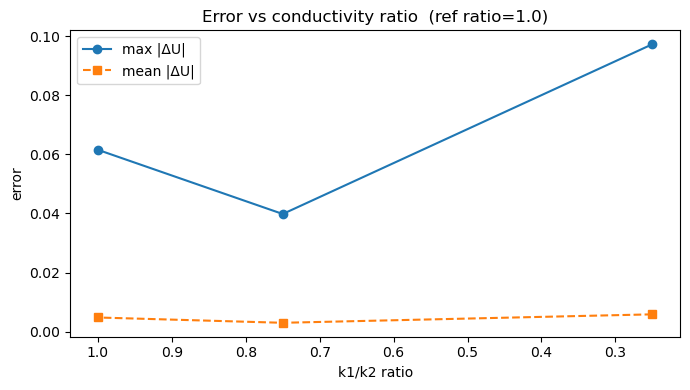

In [28]:
# Max absolute error (over z and t) for each k1 — shows trend with ratio
ratios    = [k1 / k2 for k1 in k1_list[1:]]
max_errs  = [errors_abs[k1].max().item() for k1 in k1_list[1:]]
mean_errs = [errors_abs[k1].mean().item() for k1 in k1_list[1:]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ratios, max_errs,  'o-', label='max |ΔU|')
ax.plot(ratios, mean_errs, 's--', label='mean |ΔU|')
ax.set_xlabel('k1/k2 ratio')
ax.set_ylabel('error')
ax.set_title('Error vs conductivity ratio  (ref ratio=1.0)')
ax.invert_xaxis()   # ratio decreases left to right mirrors k1_list order
ax.legend()
plt.tight_layout()
plt.show()